In [28]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pylab as plt
import seaborn as sns
import missingno as msno

In [36]:
%matplotlib inline

In [3]:
df = pd.read_csv('/chicago_crime_dataset.csv')

# 01. Data Overview
The dataset contains 1,20,759 rows and 22 original columns (the 23rd column, _year, is a redundant copy of Year), covering reported crime incidents from 2021-01-01 to 2025-12-31. Each row is a single reported incident, uniquely identified by ID (no duplicates) and Case Number (a small number of cases share a number).



In [4]:
df.shape

(120759, 23)

In [5]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,_year
0,13733090,JJ130321,01/28/2025 03:30:00 PM,076XX S RACINE AVE,0560,ASSAULT,SIMPLE,STREET,False,False,...,71.0,08A,1169643.0,1854247.0,2025,05/17/2025 03:40:52 PM,41.755554,-87.653868,"(41.755554244, -87.653867946)",2025
1,13909076,JJ344224,07/22/2025 12:40:00 PM,011XX W THORNDALE AVE,0560,ASSAULT,SIMPLE,TAVERN / LIQUOR STORE,True,False,...,77.0,08A,1167566.0,1939682.0,2025,03/14/2026 03:41:39 PM,41.990039,-87.659020,"(41.990039445, -87.659019968)",2025
2,13101860,JG295014,06/09/2023 08:23:00 PM,008XX S KOLMAR AVE,1507,PROSTITUTION,SOLICIT OFF PUBLIC WAY,STREET,True,False,...,26.0,16,1146144.0,1895827.0,2023,08/19/2023 03:40:26 PM,41.870133,-87.738933,"(41.870133029, -87.738933006)",2023
3,13701134,JH553823,12/24/2024 05:38:00 AM,043XX N KIMBALL AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,CONVENIENCE STORE,False,False,...,16.0,07,1152935.0,1928827.0,2024,11/02/2025 03:41:09 PM,41.960556,-87.713125,"(41.96055619, -87.71312483)",2024
4,13967696,JJ415709,09/15/2025 03:20:00 PM,004XX S WESTERN AVE,0312,ROBBERY,ARMED - KNIFE / CUTTING INSTRUMENT,CTA TRAIN,True,False,...,28.0,03,1160478.0,1897788.0,2025,03/14/2026 03:41:39 PM,41.875230,-87.686254,"(41.875229772, -87.686253982)",2025


In [6]:
df.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location', '_year'],
      dtype='object')

In [7]:
#Removing the redundant column '_year'
df = df[['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location', #'_year'
         ]].copy()

In [8]:
df.shape

(120759, 22)

In [9]:
df.dtypes

,0
ID,int64
Case Number,object
Date,object
Block,object
IUCR,object
Primary Type,object
Description,object
Location Description,object
Arrest,bool
Domestic,bool


In [10]:
pd.to_datetime(df['Date'])

/tmp/ipykernel_4642/524101355.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df['Date'])


,Date
0,2025-01-28 15:30:00
1,2025-07-22 12:40:00
2,2023-06-09 20:23:00
3,2024-12-24 05:38:00
4,2025-09-15 15:20:00
...,...
120754,2022-09-04 00:00:00
120755,2024-10-26 18:00:00
120756,2025-07-25 13:37:00
120757,2025-07-07 20:50:00


# 02. Missing Values

In [11]:
df.isna().sum()

,0
ID,0
Case Number,0
Date,0
Block,0
IUCR,0
Primary Type,0
Description,0
Location Description,463
Arrest,0
Domestic,0


# 03. Data Quality
 ***No duplicate records :***

*   Zero fully duplicated rows and zero duplicated ID values.
*   Four Case Number values appear twice : these are all *HOMICIDE* records where a single case includes two victims logged as separate incidents. This is expected police record-keeping behavior, not a data error.






In [12]:
df.loc[df.duplicated()]

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location


In [13]:
df.loc[df.duplicated(subset=['ID'])]

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location


In [14]:
df.loc[df.duplicated(subset=['Case Number'])]

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
21012,26791,JF260542,05/29/2022 10:49:00 PM,044XX W WALTON ST,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,37.0,23.0,01A,1146672.0,1905959.0,2022,09/19/2022 03:41:05 PM,41.897926,-87.736736,"(41.897926352, -87.736735934)"
59989,28705,JJ261204,05/19/2025 05:07:00 PM,000XX E 111TH ST,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,9.0,49.0,01A,1178327.0,1831371.0,2025,10/28/2025 03:41:02 PM,41.692587,-87.622735,"(41.692586937, -87.622735417)"
74843,27066,JF401101,09/18/2022 05:00:00 PM,061XX S EVANS AVE,0110,HOMICIDE,FIRST DEGREE MURDER,HALLWAY,True,False,...,20.0,42.0,01A,1182280.0,1864386.0,2022,09/25/2022 03:42:55 PM,41.783093,-87.607243,"(41.783093446, -87.607243127)"
103562,28198,JH317789,06/23/2024 08:44:00 AM,123XX S HALSTED ST,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,9.0,53.0,01A,1173228.0,1823102.0,2024,07/22/2025 03:42:18 PM,41.670009,-87.641647,"(41.670009388, -87.641646732)"


In [15]:
df.loc[df.duplicated(subset=['Date'])]

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
1648,12790863,JF351916,08/10/2022 12:00:00 AM,077XX S KINGSTON AVE,0810,THEFT,OVER $500,APARTMENT,False,False,...,7.0,43.0,06,1194535.0,1854096.0,2022,01/03/2023 03:40:27 PM,41.754564,-87.562651,"(41.754564201, -87.5626512)"
2275,13687715,JH536237,12/07/2024 11:00:00 PM,008XX W 115TH ST,031A,ROBBERY,ARMED - HANDGUN,STREET,False,False,...,21.0,75.0,03,1172737.0,1828585.0,2024,11/02/2025 03:41:09 PM,41.685066,-87.643283,"(41.685066437, -87.643283025)"
2358,12462232,JE348869,08/18/2021 05:00:00 PM,003XX N STATE ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,42.0,8.0,14,1176300.0,1902537.0,2021,08/26/2021 03:40:27 PM,41.887919,-87.628019,"(41.887919288, -87.628019052)"
2574,13725608,JJ121247,01/20/2025 09:00:00 AM,024XX W BELMONT AVE,4650,OTHER OFFENSE,SEX OFFENDER - FAIL TO REGISTER,POLICE FACILITY / VEHICLE PARKING LOT,True,False,...,47.0,5.0,26,1159392.0,1921181.0,2025,11/02/2025 03:41:09 PM,41.939444,-87.689597,"(41.939444419, -87.689596768)"
2603,12887976,JF468810,11/09/2022 12:00:00 AM,007XX E 114TH ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,9.0,50.0,07,1183427.0,1829539.0,2022,01/03/2023 03:40:27 PM,41.687443,-87.604120,"(41.687442712, -87.604120378)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120751,13344234,JH123163,01/21/2024 05:30:00 PM,002XX N KOLIN AVE,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,...,28.0,26.0,15,1147359.0,1900779.0,2024,12/21/2024 03:40:46 PM,41.883699,-87.734345,"(41.883698723, -87.73434544)"
120752,12851237,JF424836,10/06/2022 09:00:00 PM,023XX W POLK ST,0560,ASSAULT,SIMPLE,RESIDENCE - YARD (FRONT / BACK),False,True,...,28.0,28.0,08A,1160955.0,1896379.0,2022,01/03/2023 03:40:27 PM,41.871353,-87.684542,"(41.871353464, -87.68454173)"
120753,13014252,JG190502,02/27/2023 11:00:00 AM,082XX S HOMAN AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,False,False,...,18.0,70.0,11,1155149.0,1849862.0,2023,08/19/2023 03:40:26 PM,41.743823,-87.707102,"(41.743822933, -87.707102233)"
120754,12816225,JF383003,09/04/2022 12:00:00 AM,044XX S ALBANY AVE,1365,CRIMINAL TRESPASS,TO RESIDENCE,RESIDENCE,False,False,...,14.0,58.0,26,1156440.0,1875105.0,2022,01/03/2023 03:40:27 PM,41.813068,-87.701692,"(41.813067574, -87.701692471)"


In [16]:
df.query('Date == "08/10/2022 12:00:00 AM"')

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
358,12789885,JF352001,08/10/2022 12:00:00 AM,058XX N RIDGE AVE,0820,THEFT,$500 AND UNDER,NURSING / RETIREMENT HOME,False,False,...,48.0,77.0,06,1165024.0,1939181.0,2022,01/03/2023 03:40:27 PM,41.988719,-87.668384,"(41.988719229, -87.668384208)"
1648,12790863,JF351916,08/10/2022 12:00:00 AM,077XX S KINGSTON AVE,0810,THEFT,OVER $500,APARTMENT,False,False,...,7.0,43.0,06,1194535.0,1854096.0,2022,01/03/2023 03:40:27 PM,41.754564,-87.562651,"(41.754564201, -87.5626512)"
7141,12790532,JF351452,08/10/2022 12:00:00 AM,052XX W LAKE ST,1320,CRIMINAL DAMAGE,TO VEHICLE,OTHER (SPECIFY),False,False,...,37.0,25.0,14,1141427.0,1902029.0,2022,01/03/2023 03:40:27 PM,41.887240,-87.756098,"(41.887240429, -87.756097659)"
39296,12790013,JF352021,08/10/2022 12:00:00 AM,080XX S HALSTED ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,...,21.0,71.0,15,1172363.0,1851642.0,2022,01/03/2023 03:40:27 PM,41.748346,-87.643976,"(41.748346408, -87.643976326)"
50441,12798556,JF362010,08/10/2022 12:00:00 AM,009XX N ST LOUIS AVE,0265,CRIMINAL SEXUAL ASSAULT,AGGRAVATED - OTHER,RESIDENCE,True,True,...,27.0,23.0,02,1152875.0,1905984.0,2022,01/30/2023 03:40:50 PM,41.897874,-87.713952,"(41.897874329, -87.713952097)"
116335,12819667,JF387041,08/10/2022 12:00:00 AM,054XX W HUTCHINSON ST,1120,DECEPTIVE PRACTICE,FORGERY,OTHER (SPECIFY),False,False,...,38.0,15.0,10,1139399.0,1927728.0,2022,01/03/2023 03:40:27 PM,41.957798,-87.762917,"(41.957798489, -87.762917401)"


In [17]:
df['District'].value_counts()

,count
District,
11,8192
8,7509
6,7169
1,6910
12,6625
4,6518
25,6350
18,6268
3,6003


# 04. Data Analysis

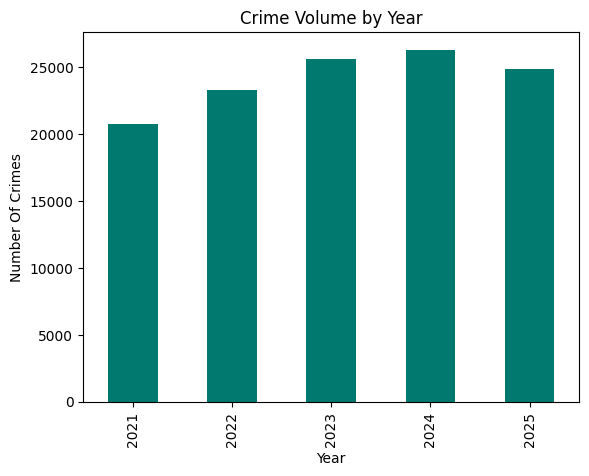

In [18]:
# Crime Volume By Year
ax = df['Year'].value_counts().sort_index().plot(kind='bar', color='#01796F', title='Crime Volume by Year',)
ax.set_ylabel('Number Of Crimes')
plt.show()

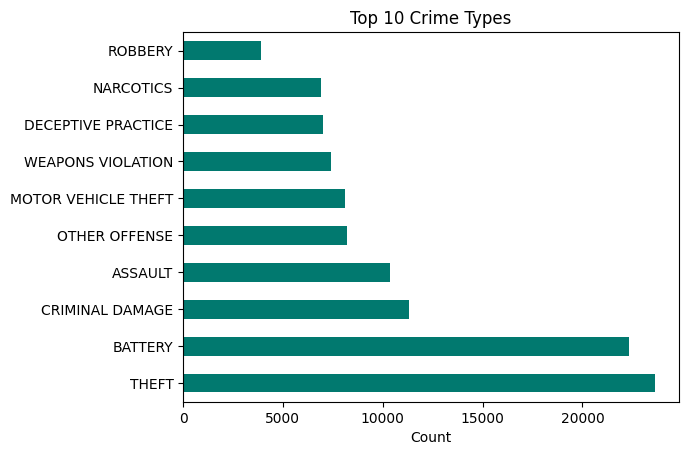

In [19]:
# Crime Type Distribution
ax = df['Primary Type'].value_counts().head(10).plot(kind='barh',color='#01796F', title='Top 10 Crime Types')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.show()

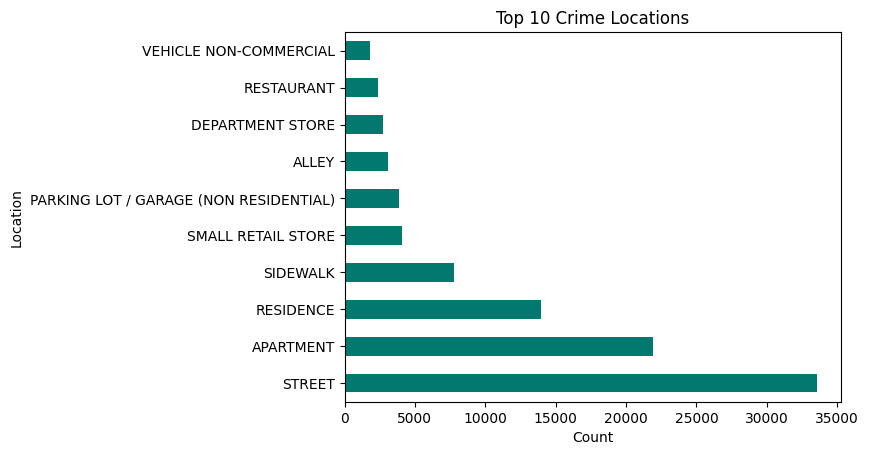

In [20]:
# Location Distribution
ax = df['Location Description'].value_counts().head(10).plot(kind='barh',color='#01796F', title='Top 10 Crime Locations')
ax.set_xlabel('Count')
ax.set_ylabel('Location')
plt.show()

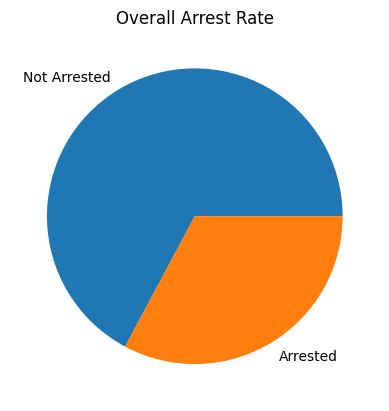

In [44]:
ax = df['Arrest'].value_counts().plot(kind='pie',labels=['Not Arrested', 'Arrested'], title='Overall Arrest Rate')
ax.set_ylabel('')
plt.show()